In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
 
 
# Ajustar path según estructura del proyecto
df = pd.read_csv("../Exploracion/BD_Adult_income/Adult_income_dataset.csv",header=0, na_values='?')
 
# Vista inicial de los datos
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# =====================================
# Revisión de valores faltantes
# =====================================
print("Valores faltantes por columna:\n", df.isna().sum())
 
# Estrategia de tratamiento: reemplazo con 'Unknown' en categóricas
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
print("\nValores faltantes después del tratamiento:\n", df.isna().sum())

Valores faltantes por columna:
 age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Valores faltantes después del tratamiento:
 age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [4]:
df.dtypes

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

In [5]:
# =====================================
# Estadísticas descriptivas univariadas
# =====================================
# Variables numéricas
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe()
 
# Variables categóricas
df[categorical_cols].describe()

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


age: 216 outliers detectados


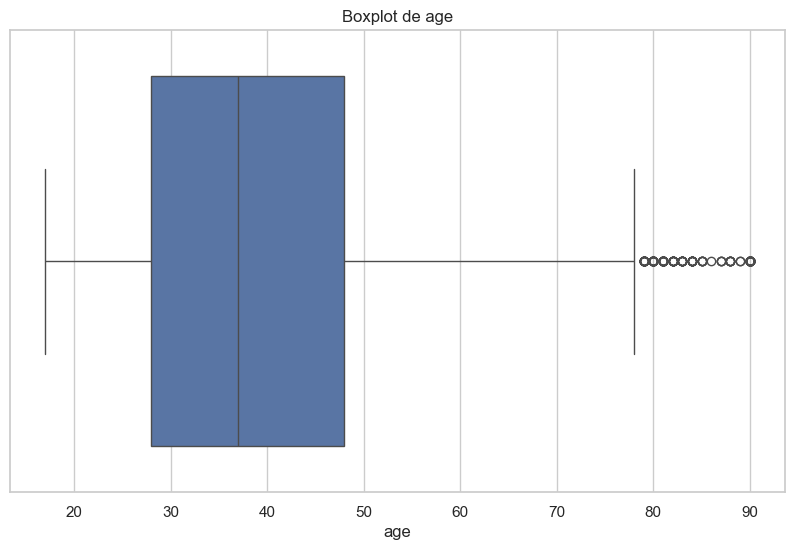

fnlwgt: 1453 outliers detectados


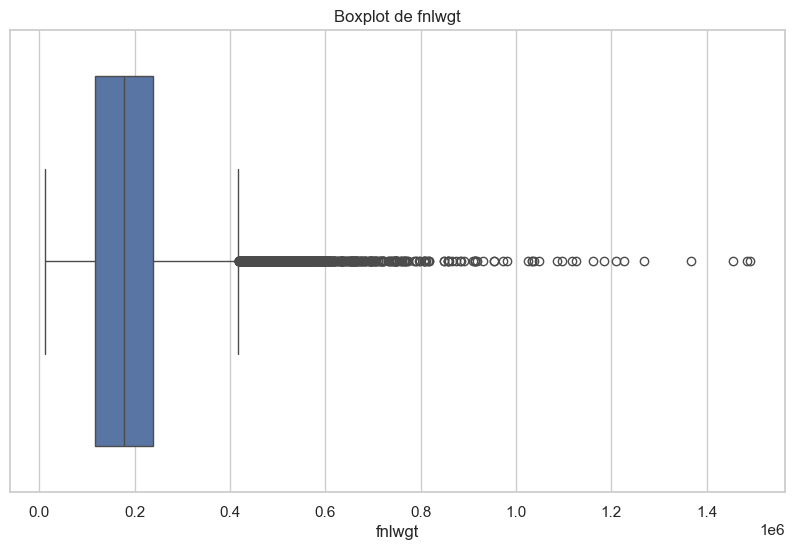

educational-num: 1794 outliers detectados


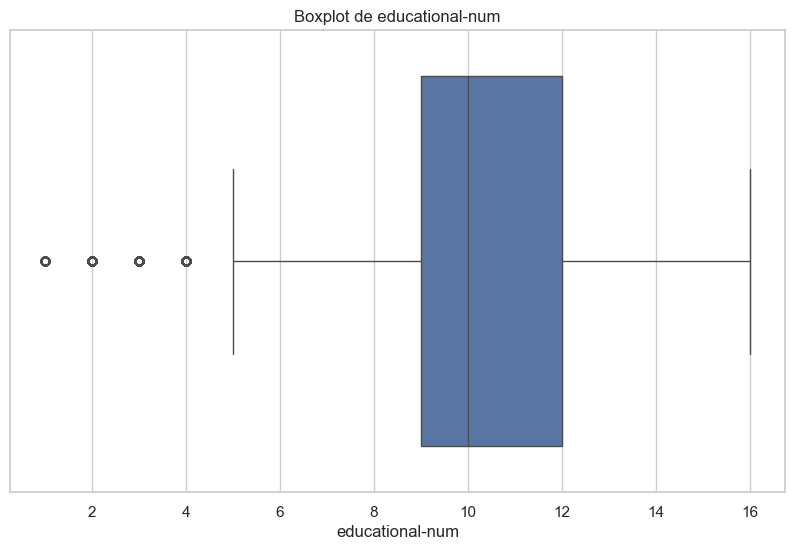

capital-gain: 4035 outliers detectados


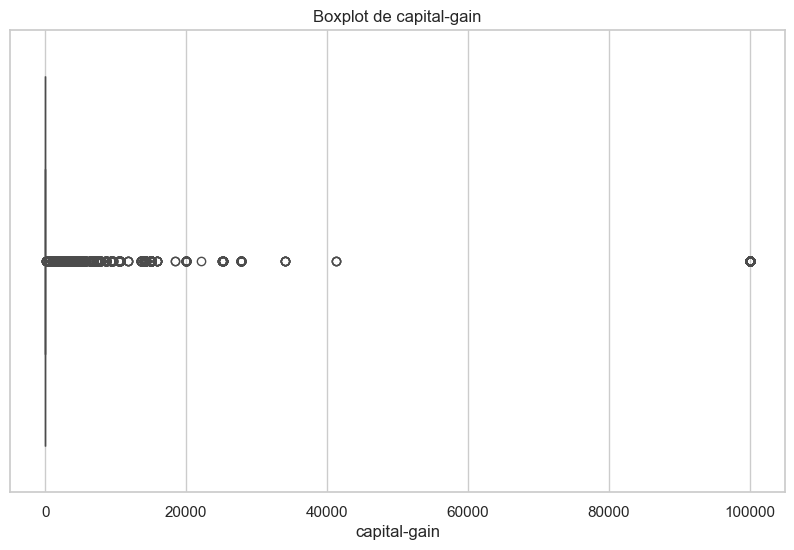

capital-loss: 2282 outliers detectados


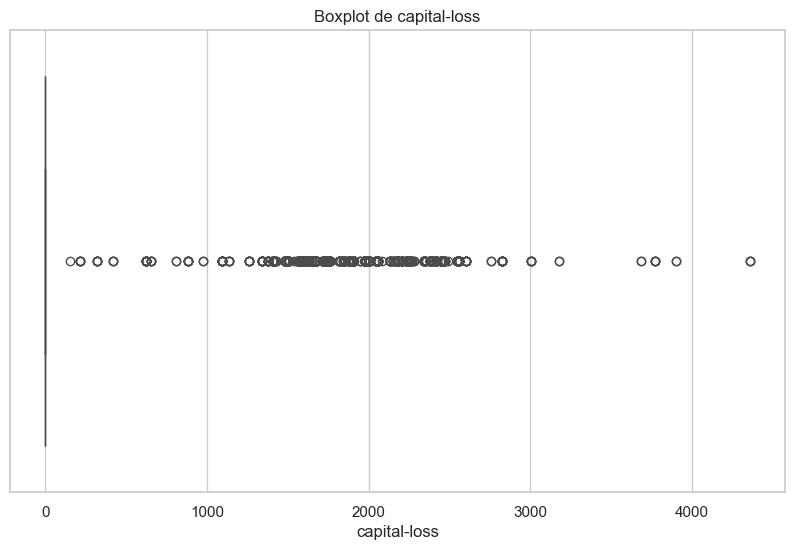

hours-per-week: 13496 outliers detectados


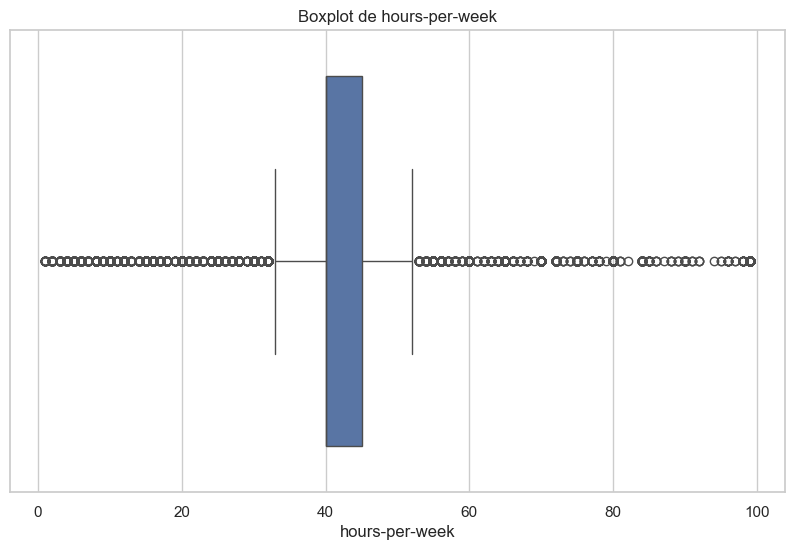

In [6]:
# =====================================
# Detección de outliers (valores atípicos)
# =====================================
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detectados")
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

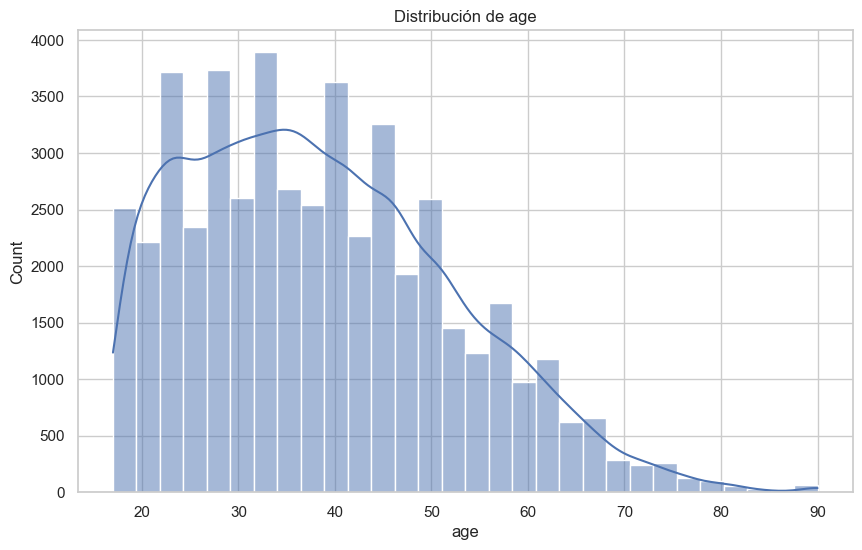

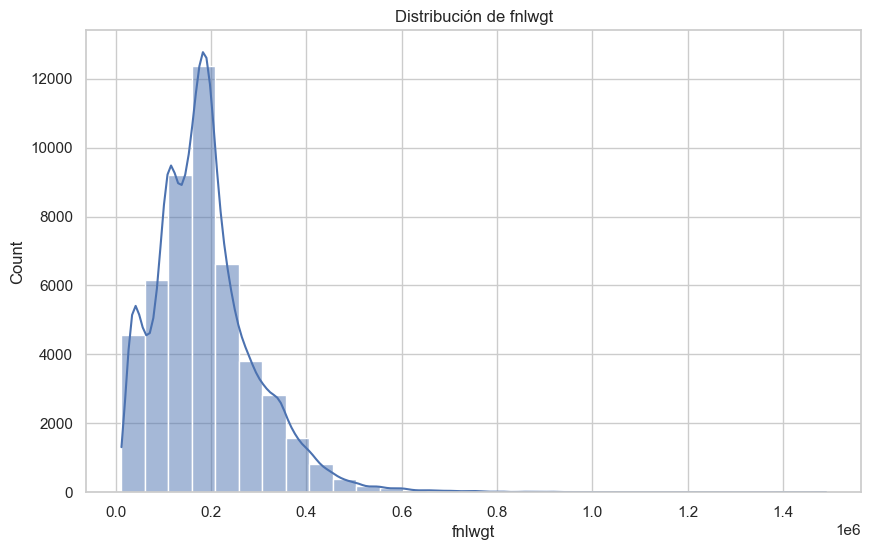

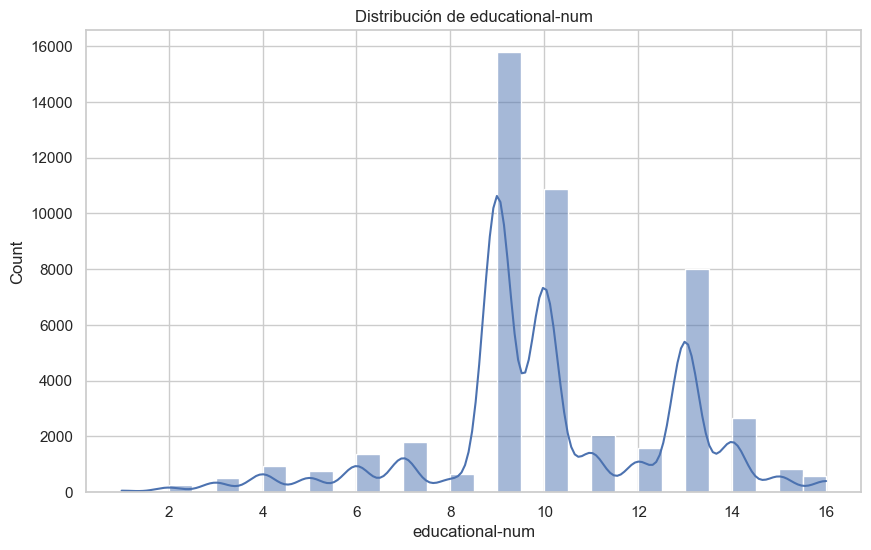

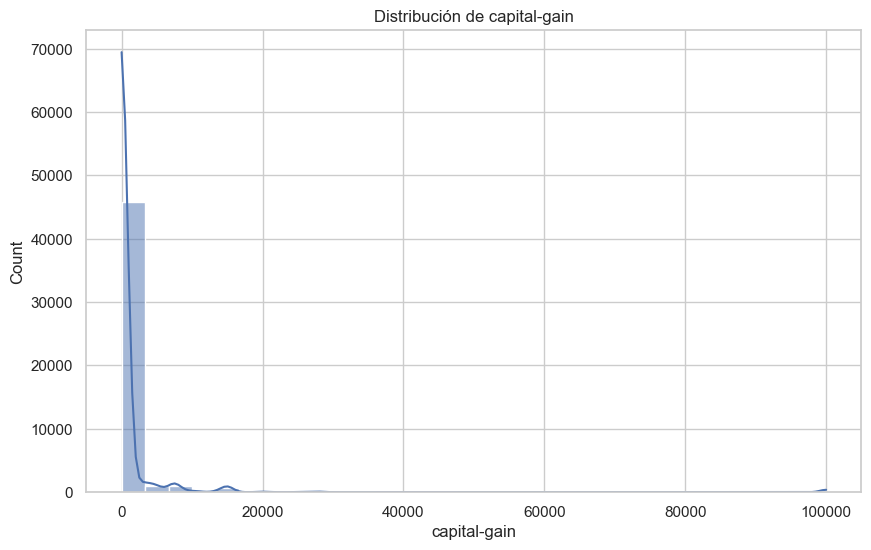

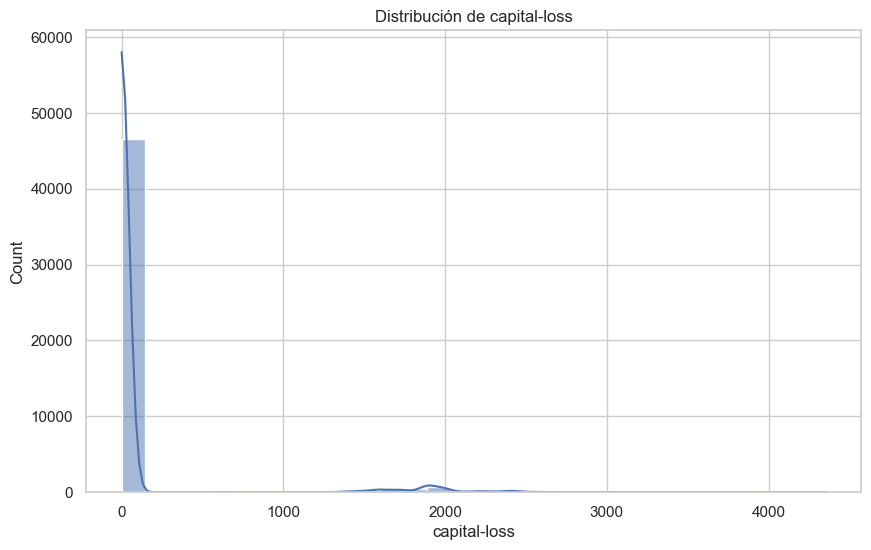

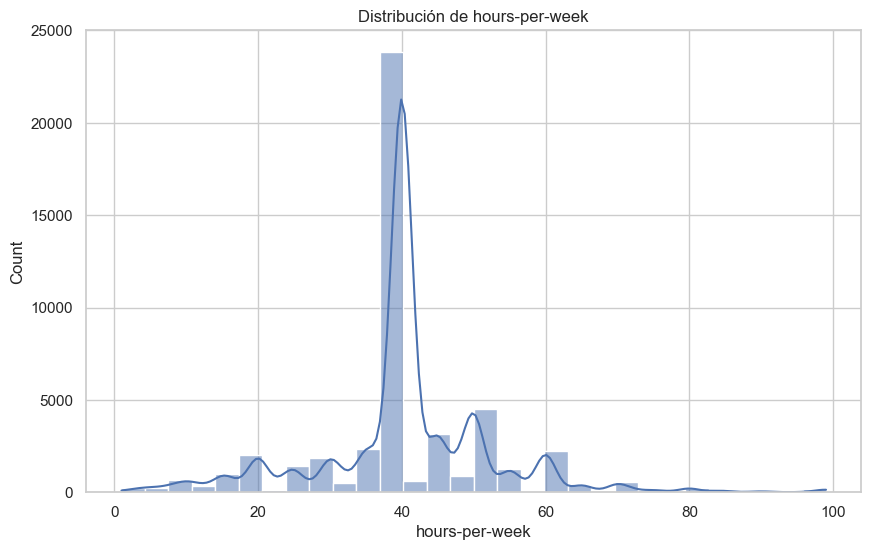

In [7]:
# =====================================
# Análisis de distribuciones
# =====================================
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()
# Transformación logarítmica para capital-gain y capital-loss
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])

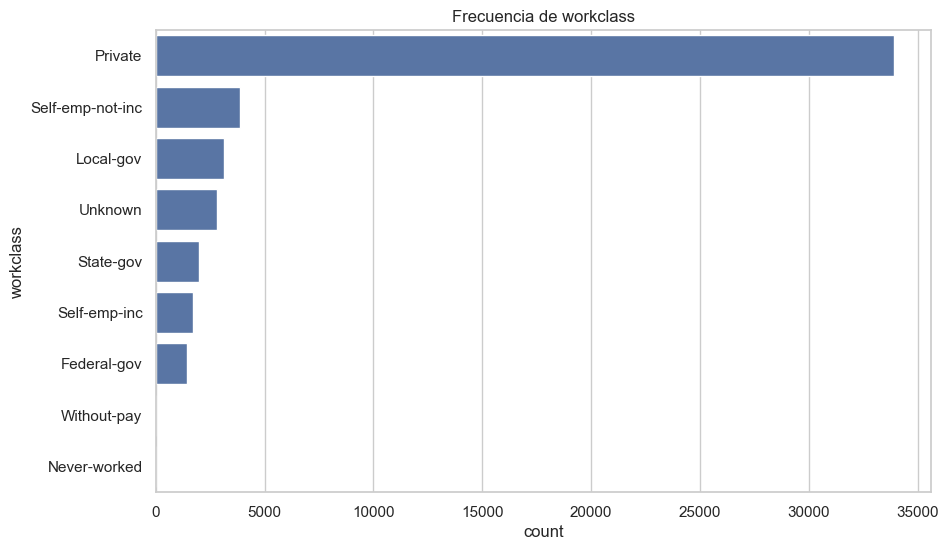

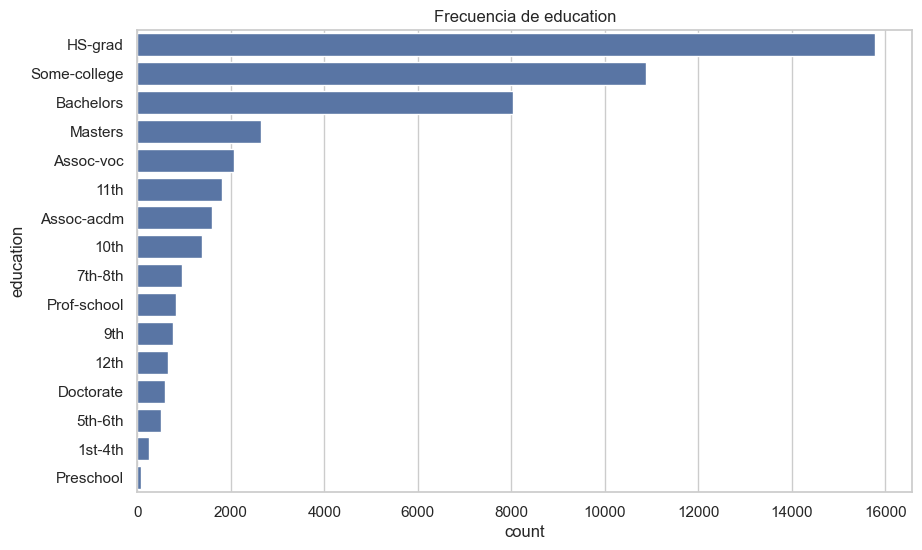

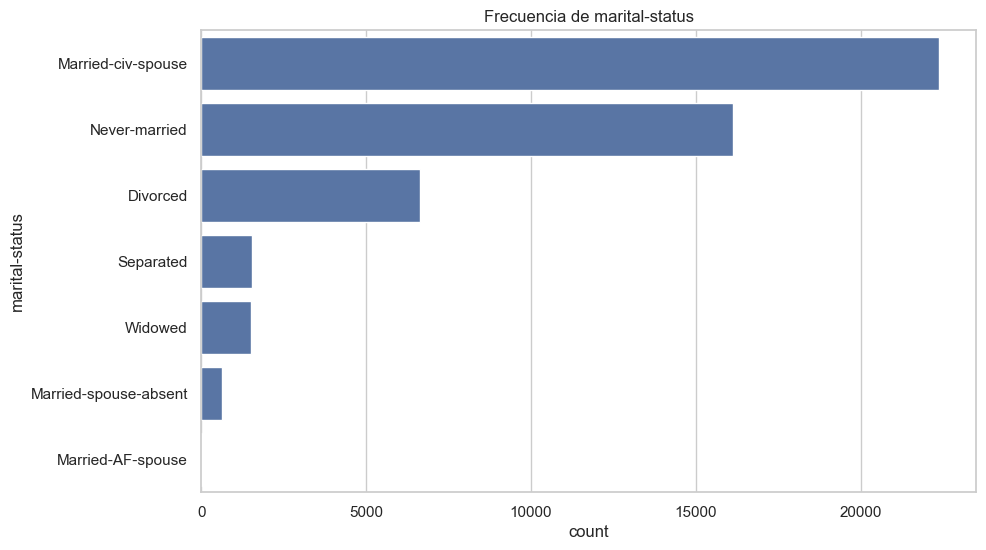

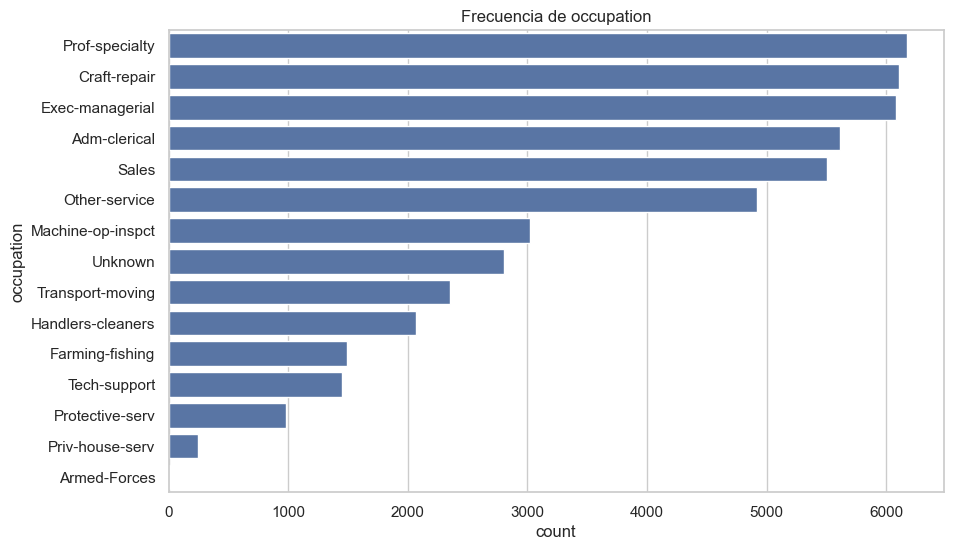

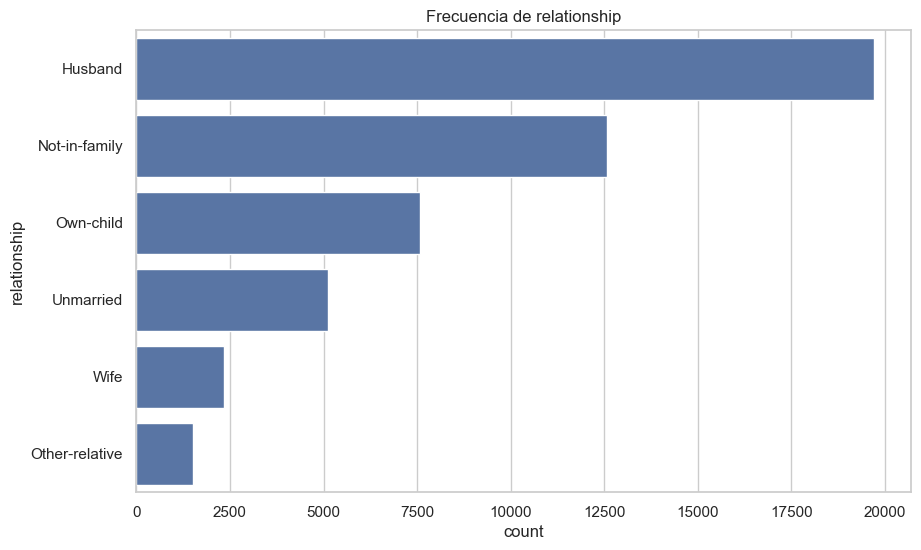

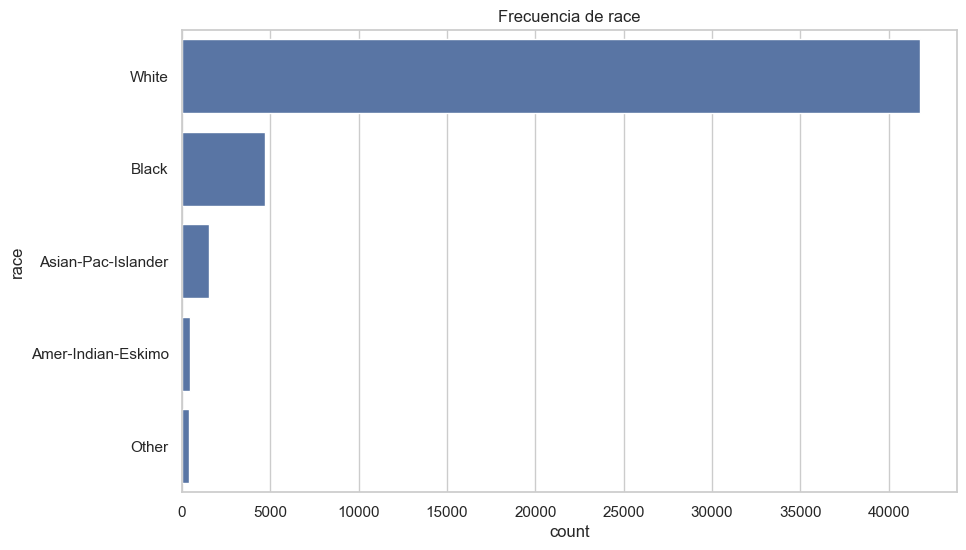

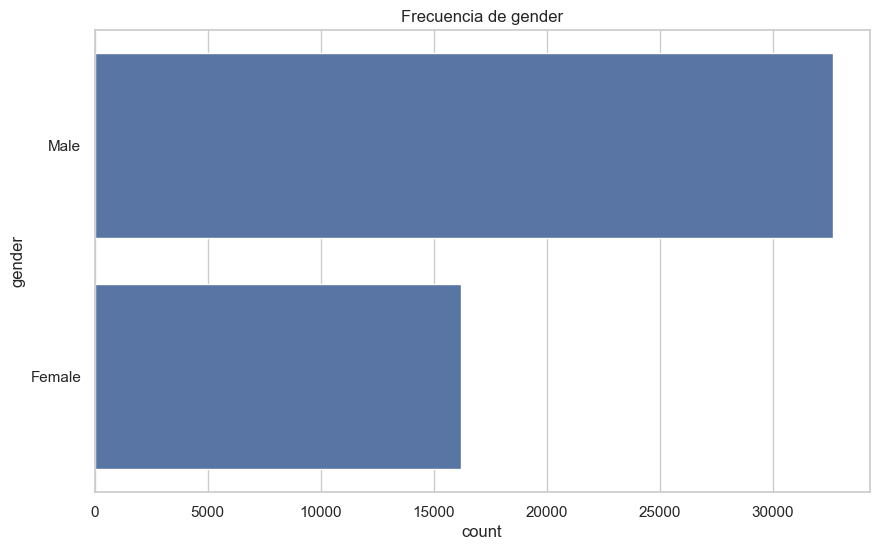

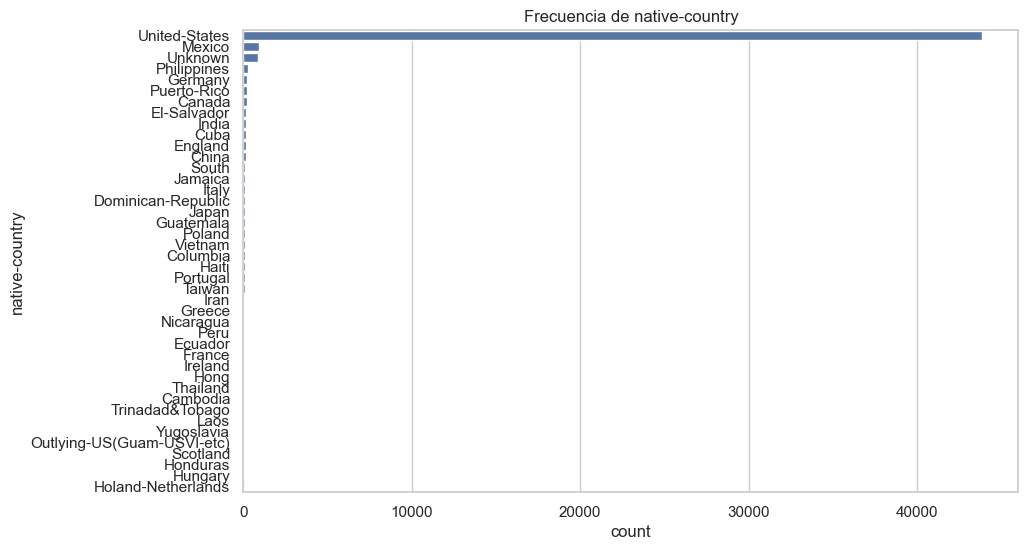

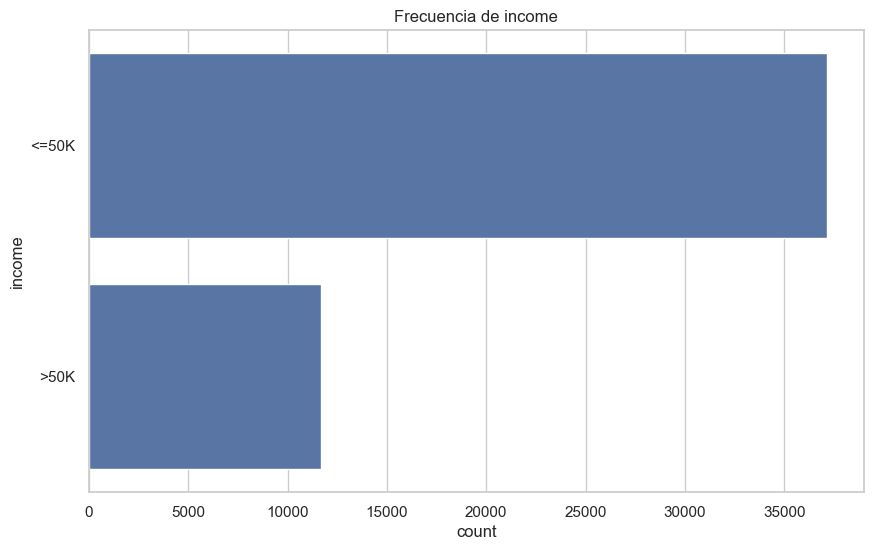

In [8]:
# =====================================
# Análisis univariado categórico
# =====================================
for col in categorical_cols:
    plt.figure()
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Frecuencia de {col}')
    plt.show()

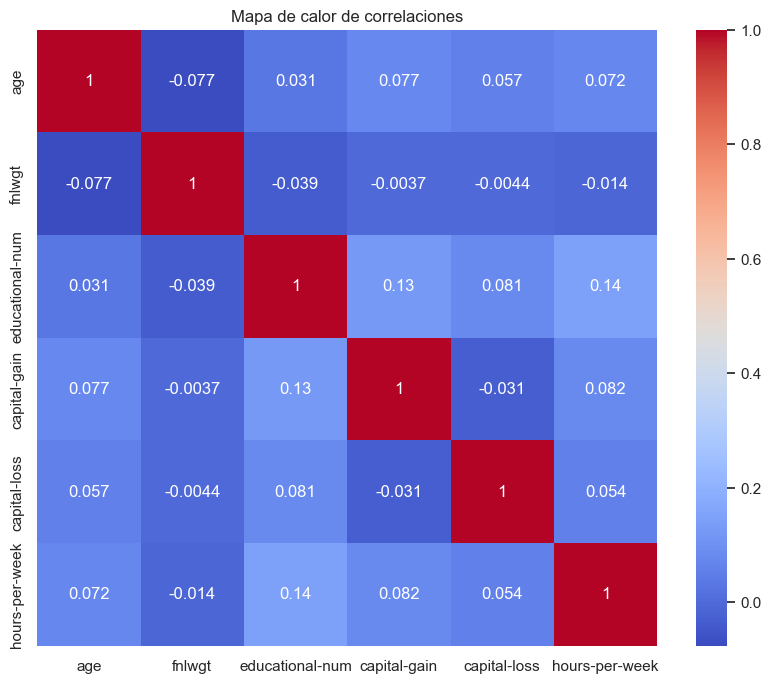

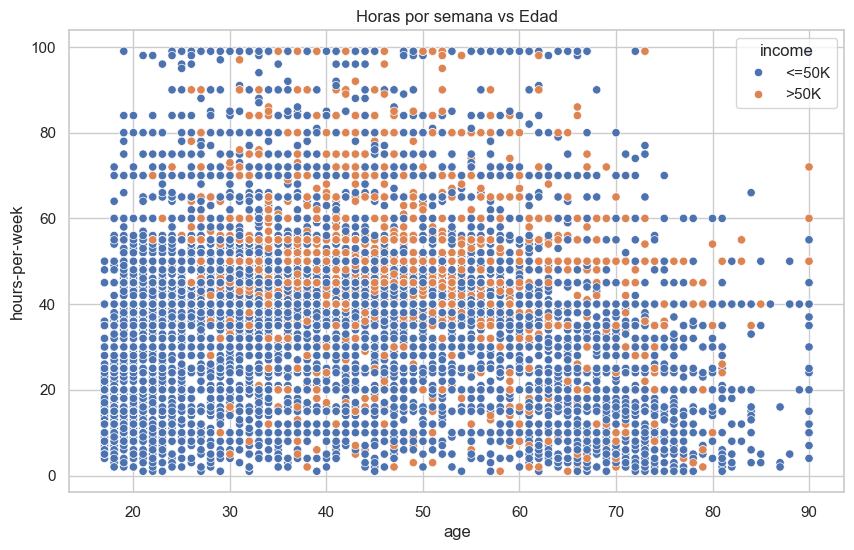

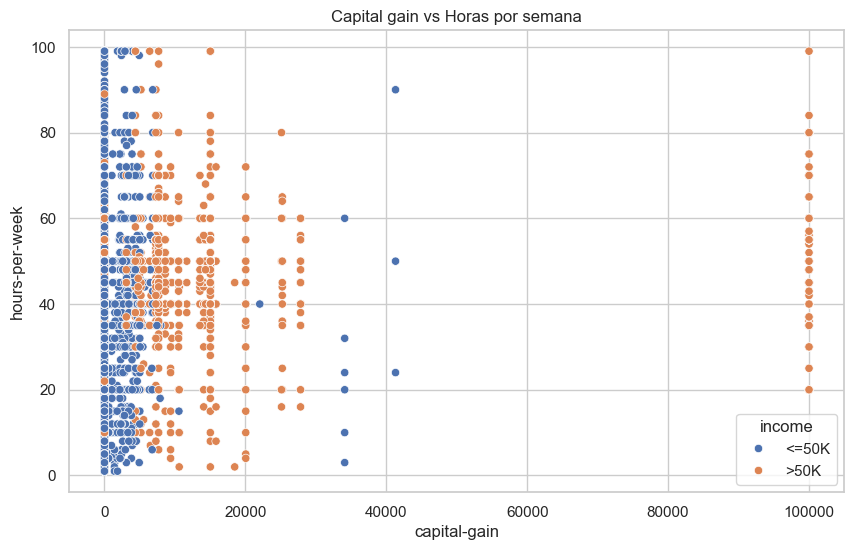

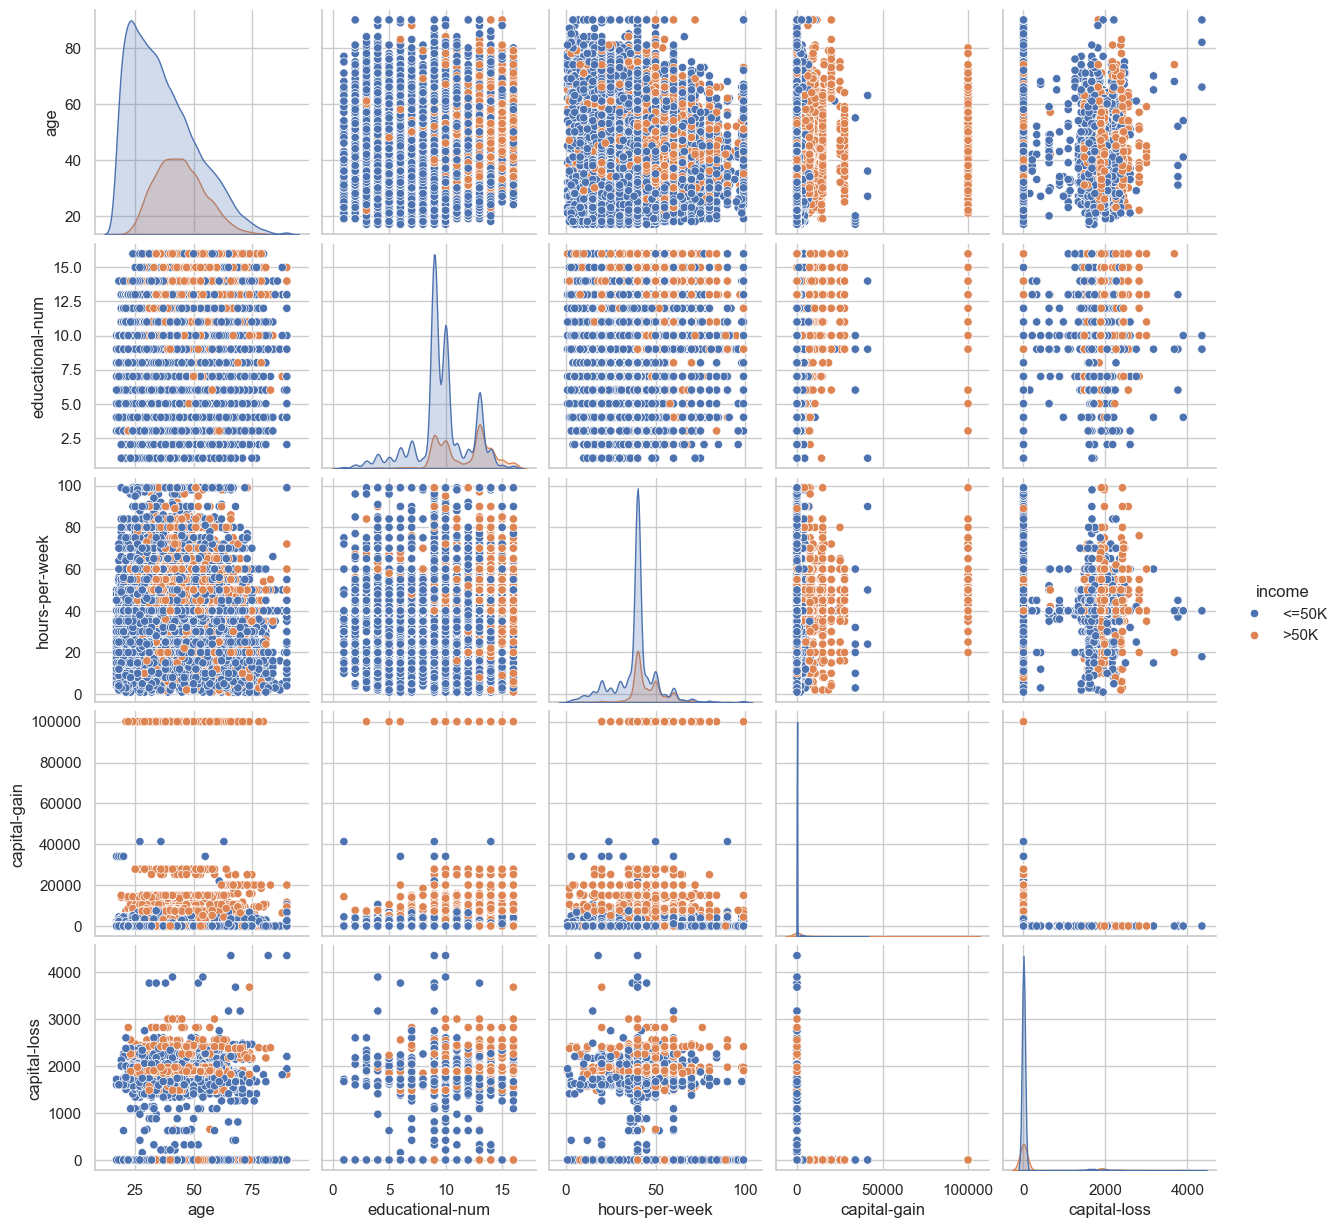

In [11]:
# =====================================
# Análisis multivariado
# =====================================
# Mapa de calor de correlaciones
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Mapa de calor de correlaciones")
plt.show()

# Scatter plots
sns.scatterplot(x='age', y='hours-per-week', hue='income', data=df)
plt.title("Horas por semana vs Edad")
plt.show()

sns.scatterplot(x='capital-gain', y='hours-per-week', hue='income', data=df)
plt.title("Capital gain vs Horas por semana")
plt.show()

# Pairplot variables seleccionadas
sns.pairplot(df[['age','educational-num','hours-per-week','capital-gain','capital-loss','income']], hue='income')
plt.show()

In [12]:
# =====================================
# Tablas cruzadas y relaciones categórico-categórico
# =====================================
income_edu = pd.crosstab(df['education'], df['income'], normalize='index') * 100
print("Porcentaje de income por educación:\n", income_edu)

Porcentaje de income por educación:
 income            <=50K       >50K
education                         
10th          93.736501   6.263499
11th          94.922737   5.077263
12th          92.694064   7.305936
1st-4th       96.761134   3.238866
5th-6th       94.695481   5.304519
7th-8th       93.507853   6.492147
9th           94.576720   5.423280
Assoc-acdm    74.203623  25.796377
Assoc-voc     74.672489  25.327511
Bachelors     58.716511  41.283489
Doctorate     27.441077  72.558923
HS-grad       84.142169  15.857831
Masters       45.088446  54.911554
Preschool     98.795181   1.204819
Prof-school   26.019185  73.980815
Some-college  81.035117  18.964883
